<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_01_KNN_Distancia_Euclidiana_interactivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador basado en Vecinos más Cercanos en número de vecinos

Este es un algoritmo de aprendizaje supervisado, pero no hay parametros que ajustar. La clasificación se basa en la relación existente entre los datos que se van a clasificar y los datos de referencia. En este algoritmo no hay un proceso de entrenamiento. Se usan todos los datos de referencia siempre.

La relación entre los datos se establece teniendo en cuenta la distancia entre ellos. La distancia se mide usando las características, cada característica es una dimensión diferente. Las propiedades de los datos de las características determinan que funciones se pueden utilizar para medir la distancia.

En este ejemplo usaremos los datos de diferenciación niños/adultos usando estatura y peso, y aplicaremos distancia euclidiana.

Text(0, 0.5, 'Peso en kilogramos')

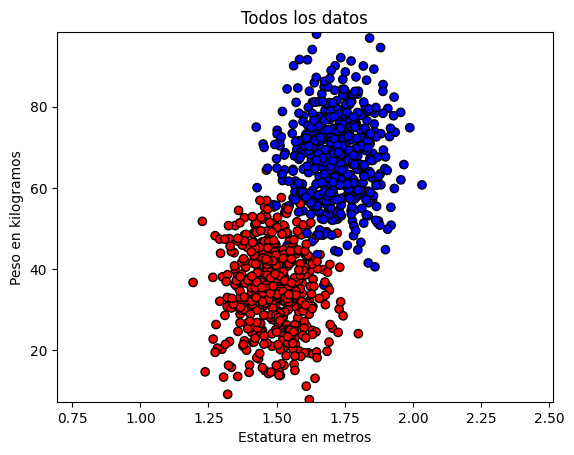

In [1]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X, y = make_blobs(n_samples=[500,500],
                  n_features = 2,
                  centers=[[1.49,35],[1.72,67]],
                  cluster_std = [[0.1,10],[0.1,10]],
                  random_state=1970)

x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")

El ejemplo lo basaremos en datos simulados que representan\
una población de personas de género masculino\
niños y adultos, y se tienen dos características de ellos: estatura y peso

Dado que las escalas de peso y estaturas son muy diferentes
(dos ordenes de magnitud)
Antes de aplicar el clasificador, debemos llevarlas
a la misma escala:
* Se resta la media
* Se divide por la desviación estándar
La media y la desviación se calculan **solo con entrenamiento**. La misma transformación se aplica a prueba.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separar antes de estandarizar: la prueba no participa en el ajuste.
X_original = X.copy()
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original, y, test_size=0.33, random_state=1970)
escalador = StandardScaler()
X_train = escalador.fit_transform(X_train_original)
X_test = escalador.transform(X_test_original)
X_estandarizada = escalador.transform(X_original)
X = X_estandarizada

Y volvemos a mostrar los datos ...

Text(0, 0.5, 'Peso estandarizado')

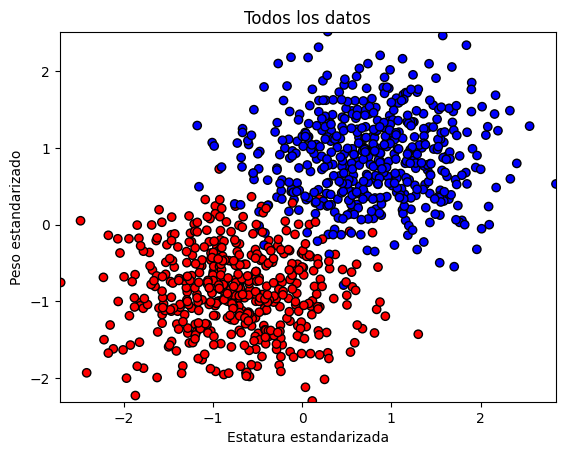

In [3]:
x_min, x_max = X[:, 0].min() - .01, X[:, 0].max() + .01
y_min, y_max = X[:, 1].min() - .01, X[:, 1].max() + .01
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura estandarizada")
plt.ylabel("Peso estandarizado")

Ahora creamos los datos de prueba y entrenamiento

In [4]:
# La separación se hizo antes de estandarizar en la celda anterior.
print(f"Entrenamiento: {len(X_train)} muestras; prueba: {len(X_test)} muestras")

Entrenamiento: 670 muestras; prueba: 330 muestras


In [5]:
from sklearn import neighbors
clfKNN = neighbors.KNeighborsClassifier(n_neighbors=21, # número de vecinos
                                        weights='distance', # pesos asignados a los vecinos al momento
                                                           # de tomar la decisión
                                                           # 'uniform', 'distance'
                                        algorithm='brute', # optimiza la ejecución del clasificador
                                                           # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
                                        p=2, # usado para la fórmula de la distancia de Minkowski
                                        metric='minkowski')
clfKNN.fit(X_train,y_train)
y_esperado = y_test
y_predicho = clfKNN.predict(X_test)

In [6]:
clfKNN

KNeighborsClassifier(algorithm='brute', n_neighbors=21, weights='distance')

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
print(accuracy_score(y_esperado,y_predicho))
print(recall_score(y_esperado,y_predicho))
print(precision_score(y_esperado,y_predicho))
print(confusion_matrix(y_esperado,y_predicho))

0.9757575757575757
0.9704142011834319
0.9820359281437125
[[158   3]
 [  5 164]]


Como se puede ver, el sistema es capaz de clasificar\
correctamente mas del 90% de los datos de prueba

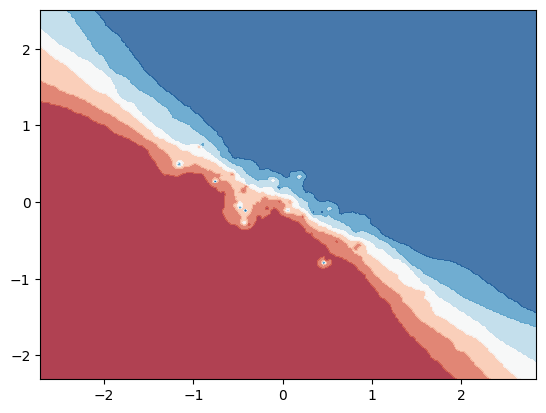

In [8]:
Z = clfKNN.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8)

Y esto es lo que el sistema sabe\
la elipse roja representa los niños\
el resto lo considera adultos

## 1. Accuracy frente al número de vecinos K

Evaluamos **K = 5, 10, 15, …, 200** sobre la misma partición de prueba.
Se conserva la configuración del ejemplo: distancia euclidiana y votos ponderados por distancia (`weights='distance'`).

$$\mathrm{Accuracy}=\frac{\text{predicciones correctas}}{\text{total de muestras de prueba}}$$

Esta curva es exploratoria: si se utiliza para elegir K, se necesita validación cruzada o un conjunto de validación y una prueba final independiente para estimar el desempeño del modelo seleccionado.

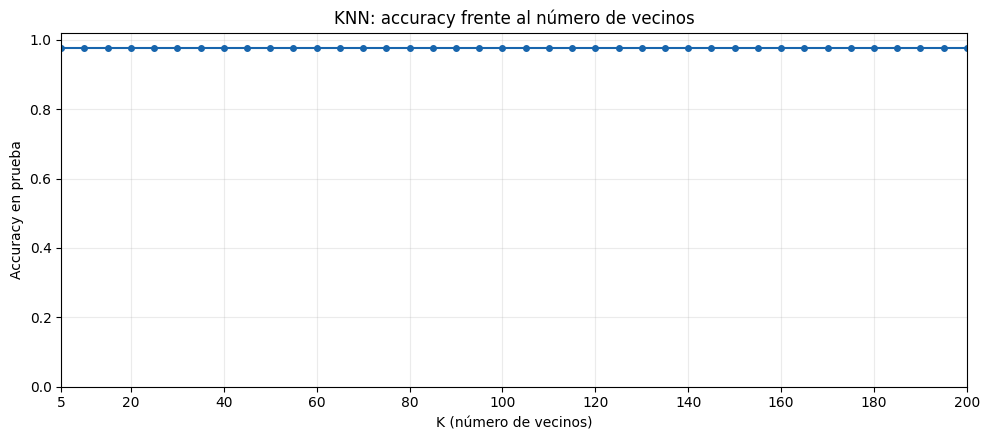

Muestras de prueba: 330
Accuracy observado: 0.9758 a 0.9758


In [9]:
from sklearn.base import clone

valores_k = np.arange(5, 201, 5)
if len(X_train) < valores_k.max():
    raise ValueError("Se necesitan al menos 200 muestras de entrenamiento.")
accuracy_por_k = []
for k in valores_k:
    modelo_k = clone(clfKNN).set_params(n_neighbors=int(k))
    modelo_k.fit(X_train, y_train)
    accuracy_por_k.append(accuracy_score(y_test, modelo_k.predict(X_test)))
accuracy_por_k = np.asarray(accuracy_por_k)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(valores_k, accuracy_por_k, 'o-', color='#1765ad', markersize=4)
ax.set(xlabel='K (número de vecinos)', ylabel='Accuracy en prueba',
       title='KNN: accuracy frente al número de vecinos', xlim=(5, 200), ylim=(0, 1.02))
ax.set_xticks([5] + list(range(20, 201, 20)))
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
print(f"Muestras de prueba: {len(y_test)}")
print(f"Accuracy observado: {accuracy_por_k.min():.4f} a {accuracy_por_k.max():.4f}")

**Observación para estos datos:** con la semilla y configuración originales, los 40 valores evaluados producen un accuracy de 0.9758 (97.58%). Por eso la curva es horizontal: variar K puede cambiar las regiones sin cambiar el número de aciertos en estas 330 muestras de prueba. No se modificaron los datos para forzar una variación.

Resultados de validación cruzada (5 particiones)
------------------------------------------------------------------
Indicador        K óptimo*          Media       Desv. estándar
f1                      95       0.975642             0.016544
auc                     50       0.997861             0.001457
log_loss                35       0.062027             0.022767
brier                   55       0.018784             0.008151


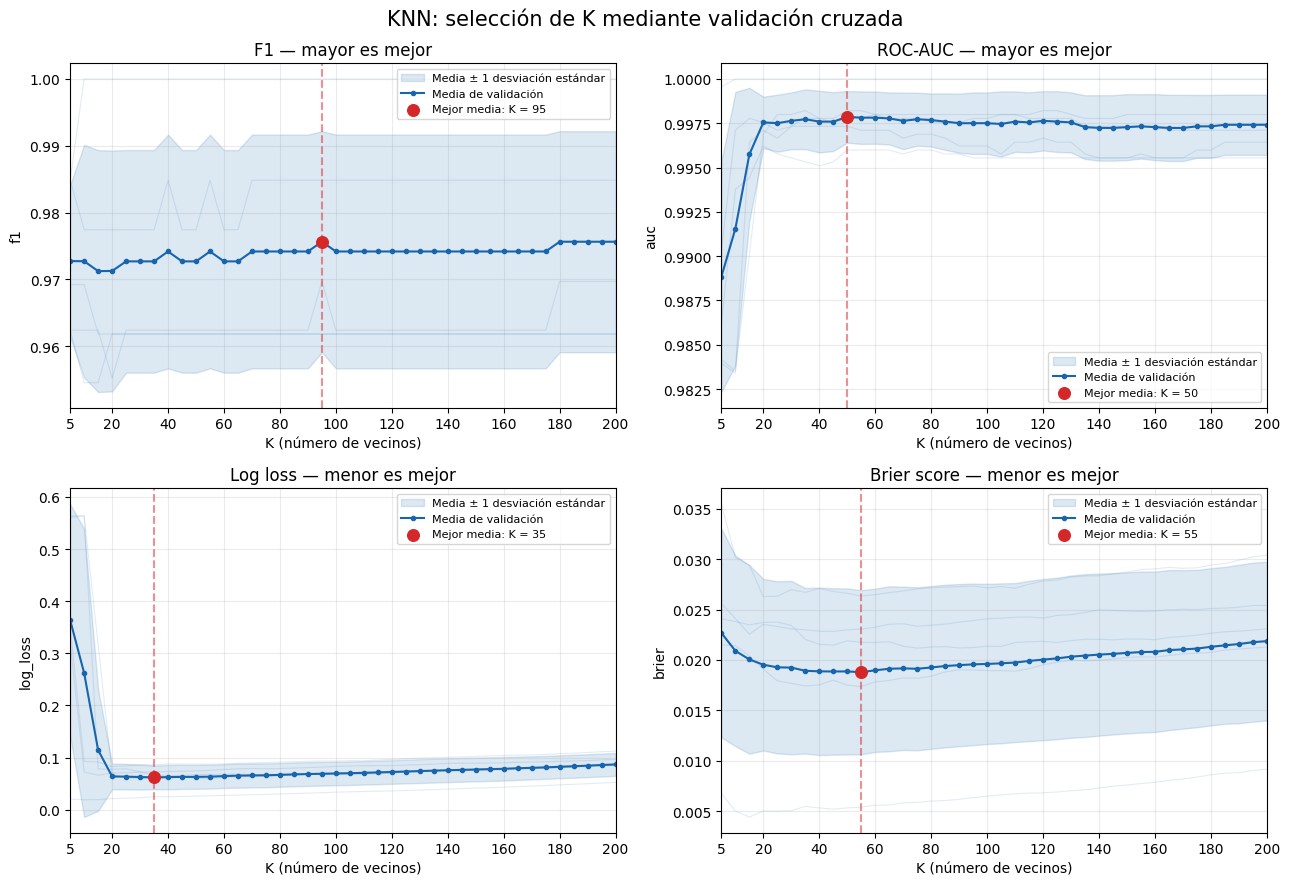


*Si hay empate exacto, se muestra el menor K.
La banda representa variación entre folds, no un intervalo de confianza.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

# Se conserva el conjunto de prueba para la evaluación final.
X_cv = X_train_original
y_cv = np.asarray(y_train)

valores_k = np.arange(5, 201, 5)

# Las mismas particiones para todos los valores de K.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1970
)
particiones = list(cv.split(X_cv, y_cv))

min_entrenamiento = min(len(indices) for indices, _ in particiones)

if valores_k.max() > min_entrenamiento:
    raise ValueError(
        f"Cada partición dispone de al menos {min_entrenamiento} "
        "muestras de entrenamiento. Reduce el máximo de K."
    )

# F1 y ROC-AUC consideran la clase 1 como positiva.
if not np.array_equal(np.unique(y_cv), [0, 1]):
    raise ValueError("Este ejemplo requiere clases codificadas como 0 y 1.")

scoring = {
    "f1": "f1",
    "auc": "roc_auc",
    "log_loss": "neg_log_loss",
    "brier": "neg_brier_score",
}

resultados = {nombre: [] for nombre in scoring}

for k in valores_k:
    # El escalador se ajusta SOLO con el entrenamiento de cada fold.
    modelo = Pipeline([
        ("escalador", StandardScaler()),
        ("knn", clone(clfKNN).set_params(n_neighbors=int(k)))
    ])

    scores = cross_validate(
        modelo,
        X_cv,
        y_cv,
        cv=particiones,
        scoring=scoring,
        n_jobs=1,
        error_score="raise"
    )

    for nombre in scoring:
        valores = scores[f"test_{nombre}"]

        # sklearn devuelve pérdidas negativas para sus scorers.
        # Recuperamos aquí sus valores positivos.
        if nombre in ("log_loss", "brier"):
            valores = -valores

        resultados[nombre].append(valores)

# Forma: (número de valores de K, número de folds)
resultados = {
    nombre: np.asarray(valores)
    for nombre, valores in resultados.items()
}

configuracion = [
    ("f1", "F1 — mayor es mejor", True),
    ("auc", "ROC-AUC — mayor es mejor", True),
    ("log_loss", "Log loss — menor es mejor", False),
    ("brier", "Brier score — menor es mejor", False),
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 9),
    sharex=True
)

print("Resultados de validación cruzada (5 particiones)")
print("-" * 66)
print(f"{'Indicador':<15} {'K óptimo*':>10} {'Media':>14} {'Desv. estándar':>20}")

for ax, (nombre, titulo, maximizar) in zip(
    axes.ravel(), configuracion
):
    valores = resultados[nombre]
    media = valores.mean(axis=1)
    desviacion = valores.std(axis=1, ddof=1)

    indice = np.argmax(media) if maximizar else np.argmin(media)
    k_optimo = int(valores_k[indice])

    # Resultados individuales: permiten ver la variación entre folds.
    for fold in range(valores.shape[1]):
        ax.plot(
            valores_k,
            valores[:, fold],
            color="#1765ad",
            alpha=0.12,
            linewidth=0.8
        )

    ax.fill_between(
        valores_k,
        media - desviacion,
        media + desviacion,
        color="#1765ad",
        alpha=0.15,
        label="Media ± 1 desviación estándar"
    )

    ax.plot(
        valores_k,
        media,
        "o-",
        color="#1765ad",
        markersize=3,
        label="Media de validación"
    )

    ax.scatter(
        k_optimo,
        media[indice],
        color="#d62728",
        s=70,
        zorder=5,
        label=f"Mejor media: K = {k_optimo}"
    )

    ax.axvline(
        k_optimo,
        color="#d62728",
        linestyle="--",
        alpha=0.5
    )

    ax.set(
        title=titulo,
        xlabel="K (número de vecinos)",
        ylabel=nombre,
        xlim=(5, 200)
    )

    # Escala Y automática para apreciar diferencias pequeñas.
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_xticks([5] + list(range(20, 201, 20)))
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    print(
        f"{nombre:<15} {k_optimo:>10d} "
        f"{media[indice]:>14.6f} "
        f"{desviacion[indice]:>20.6f}"
    )

fig.suptitle(
    "KNN: selección de K mediante validación cruzada",
    fontsize=15
)
fig.tight_layout()
plt.show()

print("\n*Si hay empate exacto, se muestra el menor K.")
print("La banda representa variación entre folds, no un intervalo de confianza.")

Log loss y Brier score comparan las probabilidades predichas con las clases reales, mientras que accuracy solo considera si la etiqueta final fue correcta.

En tu ejemplo de KNN:

$y_i=0$: niño.

$y_i=1$: adulto.

$p_i=P(y_i=1\mid x_i)$: probabilidad estimada de que la persona sea adulta.

1. Log loss

Para clasificación binaria:

$$ \boxed{ \text{Log loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i\ln(p_i)+(1-y_i)\ln(1-p_i) \right] } $$

Aquí $\ln$ es el logaritmo natural. Para cada muestra, la expresión se simplifica a:

|Clase real	|Pérdida de la muestra
|---|---|
|$y_i=1$	|$-\ln(p_i)$
|$y_i=0$	|$-\ln(1-p_i)$

Es decir, toma el negativo del logaritmo de la probabilidad asignada a la clase correcta.

Por ejemplo, para una persona adulta:

|Probabilidad de adulto $p_i$	|Log loss individual
|---|---|
0.99	|0.0101
0.80	|0.2231
0.50	|0.6931
0.20	|1.6094
0.01	|4.6052

Cuanto más seguro esté el modelo de una predicción incorrecta, mayor será la penalización. El mejor valor es 0 y no existe un límite superior finito.

2. Brier score

En clasificación binaria se calcula como:

$$ \boxed{ \text{Brier score} = \frac{1}{N} \sum_{i=1}^{N}(p_i-y_i)^2 } $$

Es el promedio del error cuadrático entre la probabilidad predicha y la clase real.

Para una persona adulta, $y_i=1$:

Probabilidad de adulto $p_i$	|Brier individual
|---|---|
0.99	|$(0.99-1)^2=0.0001$
0.80	|$(0.80-1)^2=0.0400$
0.50	|$(0.50-1)^2=0.2500$
0.20	|$(0.20-1)^2=0.6400$
0.01	|$(0.01-1)^2=0.9801$

Con esta definición binaria, sus valores están entre 0 y 1; menor es mejor.

## 2. Regiones de clasificación con un deslizador para K

Ejecute las celdas en orden y mueva la barra entre **5 y 200**, de uno en uno.
La gráfica se actualiza al soltar el deslizador. El fondo representa la **clase predicha** y la línea negra su frontera; los puntos representan las clases reales del conjunto de prueba y las cruces señalan errores.

Los ejes están estandarizados. Solo cambia K: se conservan los datos, la escala y los demás parámetros. El título muestra el accuracy para el K seleccionado.

Se requiere `ipywidgets`. Si falta, ejecute `%pip install ipywidgets` en una celda y vuelva a ejecutar esta sección (reinicie el kernel si su entorno lo solicita). En Google Colab se habilita automáticamente su gestor de widgets. La interacción requiere un kernel activo; una vista previa estática puede no mostrar el deslizador.

In [11]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from google.colab import output as salida_colab
except ImportError:
    pass
else:
    salida_colab.enable_custom_widget_manager()

# Malla independiente de tamaño moderado para mantener la interacción ágil.
x_malla = np.linspace(X[:, 0].min() - 0.25, X[:, 0].max() + 0.25, 160)
y_malla = np.linspace(X[:, 1].min() - 0.25, X[:, 1].max() + 0.25, 160)
xx_interactivo, yy_interactivo = np.meshgrid(x_malla, y_malla)
puntos_malla = np.c_[xx_interactivo.ravel(), yy_interactivo.ravel()]
colores_regiones = ListedColormap(['#f7c6c6', '#c4dcf4'])
colores_puntos = ListedColormap(['#d62728', '#1765ad'])

# Cache: volver a un K ya explorado no repite las predicciones.
from functools import lru_cache
@lru_cache(maxsize=196)
def resultados_para_k(k):
    modelo = clone(clfKNN).set_params(n_neighbors=int(k))
    modelo.fit(X_train, y_train)
    regiones = modelo.predict(puntos_malla).reshape(xx_interactivo.shape)
    predicciones = modelo.predict(X_test)
    return regiones, predicciones

def mostrar_clasificacion(k):
    regiones, predicciones = resultados_para_k(k)
    accuracy = accuracy_score(y_test, predicciones)
    errores = predicciones != y_test
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.contourf(xx_interactivo, yy_interactivo, regiones,
                levels=[-0.5, 0.5, 1.5], cmap=colores_regiones)
    if np.unique(regiones).size > 1:
        ax.contour(xx_interactivo, yy_interactivo, regiones,
                   levels=[0.5], colors='black', linewidths=1)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colores_puntos,
               vmin=0, vmax=1, s=24, edgecolors='white', linewidths=0.4)
    ax.scatter(X_test[errores, 0], X_test[errores, 1],
               marker='x', c='black', s=55, linewidths=1.3)
    ax.set(xlabel='Estatura estandarizada', ylabel='Peso estandarizado',
           title=f'K = {k} | Accuracy en prueba = {accuracy:.4f} ({accuracy:.2%})',
           xlim=(x_malla[0], x_malla[-1]), ylim=(y_malla[0], y_malla[-1]))
    ax.legend(handles=[
        Patch(facecolor='#f7c6c6', label='Región: niños (0)'),
        Patch(facecolor='#c4dcf4', label='Región: adultos (1)'),
        Line2D([], [], marker='o', color='none', markerfacecolor='#d62728', label='Prueba: niños'),
        Line2D([], [], marker='o', color='none', markerfacecolor='#1765ad', label='Prueba: adultos'),
        Line2D([], [], marker='x', color='black', linestyle='none', label='Predicción incorrecta')
    ], fontsize=9, loc='upper left')
    fig.tight_layout()
    plt.show()
    plt.close(fig)

barra_k = widgets.IntSlider(value=21, min=5, max=200, step=1,
                            description='K:', continuous_update=False,
                            layout=widgets.Layout(width='650px'))
salida = widgets.interactive_output(mostrar_clasificacion, {'k': barra_k})
display(widgets.VBox([barra_k, salida]))